In [25]:
from pachner_traversal.utils import data_root
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
res_path = data_root / "results" / "sgd_models_dehydration" / "scale"

In [21]:
models = [
    "spheres_1024emb_24block_8head_10tet",
    "spheres_512emb_6block_4head_10tet",
    "spheres_768emb_12block_6head_10tet",
    "spheres_1536emb_32block_12head_10tet",
    "spheres_256emb_4block_4head_10tet"
]

flops_map = {
    "spheres_1024emb_24block_8head_10tet": 62_659_989_504,
    "spheres_768emb_12block_6head_10tet": 52_657_090_560,
    "spheres_512emb_6block_4head_10tet": 19_736_492_032,
    "spheres_256emb_4block_4head_10tet": 5_549_292_032,
}

In [22]:
train_losses = {}
test_losses = {}

for model in models:
    try:
        p = res_path / model / "train_losses.csv"
        data = pd.read_csv(p, index_col=0, header=None)[1]
        data.index.name = None
        data.index = data.index * flops_map[model]
        train_losses[model] = data

        p = res_path / model / "test_losses.csv"
        data = pd.read_csv(p, index_col=0, header=None)[1]
        data.index.name = None
        data.index = data.index * flops_map[model]
        test_losses[model] = data
    except:
        pass

/tmp/ipykernel_27671/1680082397.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 1e18])


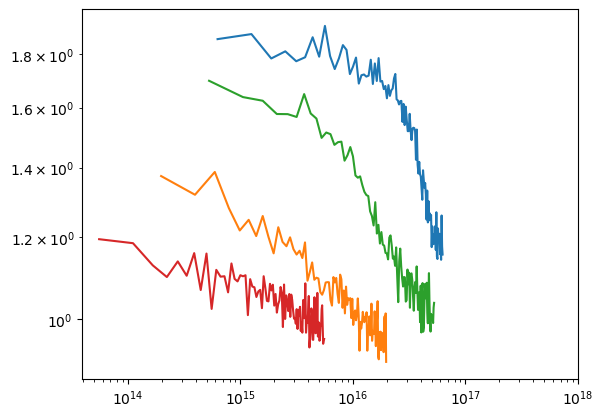

In [34]:
for model in models:
    try:
        plt.plot(train_losses[model])
    except:
        pass

plt.loglog()
plt.xlim([0, 1e18])
plt.show()

In [41]:
(1e17 / train_losses['spheres_256emb_4block_4head_10tet'].index.max())

np.float64(18.020316722088126)

In [40]:
1e17 / train_losses['spheres_512emb_6block_4head_10tet'].index.max()

np.float64(5.066756535957038)

In [42]:
1e17 / train_losses['spheres_768emb_12block_6head_10tet'].index.max()

np.float64(1.899079476980507)

In [43]:
1e17 / train_losses['spheres_1024emb_24block_8head_10tet'].index.max()

np.float64(1.5959147263121762)